## Get and Format Data
### Only do this once (until someone changes the code)
1. Run all blocks in notebooks/bipartite_graph.ipynb
2. cd into notebooks
2. Run process_graphs.py
3. Run run_simulations.py (there are hyperparameters on the number of trajectories to simulate and expansion types)
4. Run this notebook

In [ ]:
# General imports
import sys
import os
import numpy as np

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv 
from torch_geometric.nn import GATv2Conv


# ----File Stitching----
# If in models folder, cd back to notebooks folder
if os.path.basename(os.getcwd()) == "models":
    os.chdir('..')
# If a file is in /src/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import from .py files 
from training import load_and_prepare_training_data, ImitationTrainer # Training script handles dataloaders 
train_dataloader, val_dataloader, static_graph = load_and_prepare_training_data()
node_dim = static_graph['x_static'].shape[1] + 1 
_, _, _, sample_event_feat = next(iter(train_dataloader))
event_dim = sample_event_feat.shape[1]

Loading imitation data...
Splitting data with 20.0% validation ratio...
Building PyTorch Train DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...
Building PyTorch Validation DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...


## Define Model

In [ ]:
# class MultiplexSeedingModel(nn.Module):
#     def __init__(self, node_dim, event_dim, edge_dim=1, hidden_dim=128):
#         super().__init__()
        
#         # Encoders
#         self.node_encoder = nn.Linear(node_dim, hidden_dim)
#         self.event_encoder = nn.Linear(event_dim, hidden_dim)
        
#         # Parallel Message Passing
#         self.conv1_1 = GATConv(hidden_dim, hidden_dim // 2, edge_dim=edge_dim)
#         self.conv2_1 = GATConv(hidden_dim, hidden_dim // 2, edge_dim=edge_dim)
        
#         self.fusion_layer = nn.Linear(hidden_dim, hidden_dim)
        
#         # Final Scorer - input dim is hidden_dim * 2 due to node + event concatenation
#         self.scorer = nn.Sequential(
#             nn.Linear(hidden_dim * 2, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, 1)
#         )

#     def forward(self, x_batch, static_graph, event_feat_batch):
#         """
#         Args:
#             x_batch: Tensor of shape [B, N, F+1] - matrix of all node embeddings, dependent on graph config 
#                 comprises imitation data results for multiple seed notification scenarios
#             static_graph: Dict of pre-loaded, unbatched PyG topology tensors - connections between nodes 
#                 static_graph['edge_index_1'], static_graph['edge_attr_1'] = simple graphs
#                 static_graph['edge_index_2'], static_graph['edge_attr_2'] = 2simplex graph
#             event_feat_batch: Tensor of shape [B, event_dim] - matrix of all event embeddings 
#                 corresponding to the seed notification scenarios
#         """
#         B, N, _ = x_batch.shape
        
#         # 1. Initial Encodings
#         x_encoded = F.relu(self.node_encoder(x_batch)) # [B, N, hidden_dim]
#         event_encoded = F.relu(self.event_encoder(event_feat_batch)) # [B, hidden_dim]
        
#         x_nodes_list = []
        
#         # 2. Sequential Message Passing (Avoid OOM on large graphs)
#         for b in range(B):
#             x_b = x_encoded[b] # [N, hidden_dim]
            
#             x_1 = F.elu(self.conv1_1(x_b, static_graph['edge_index_1'], static_graph['edge_attr_1']))
#             x_2 = F.elu(self.conv2_1(x_b, static_graph['edge_index_2'], static_graph['edge_attr_2']))
            
#             x_fused = torch.cat([x_1, x_2], dim=-1)
#             x_nodes = F.relu(self.fusion_layer(x_fused)) # [N, hidden_dim]
#             x_nodes_list.append(x_nodes)
            
#         batch_x_nodes = torch.stack(x_nodes_list) # [B, N, hidden_dim]
        
#         # 3. Contextualize with Event Features
#         # Expand event embeddings to match node dimension: [B, hidden_dim] -> [B, N, hidden_dim]
#         event_expanded = event_encoded.unsqueeze(1).expand(-1, N, -1)
        
#         # Combine node representations with the target event context
#         combined = torch.cat([batch_x_nodes, event_expanded], dim=-1) # [B, N, hidden_dim * 2]
        
#         # 4. Score Nodes
#         logits = self.scorer(combined).squeeze(-1) # [B, N]
        
#         # 5. Autoregressive Masking
#         # Mask out nodes that are already seeded (tracked in channel 0 of x_batch)
#         seed_mask = x_batch[:, :, 0].bool()
#         logits = logits.masked_fill(seed_mask, float('-1e9'))
        
#         # Return raw logits to align with BCEWithLogitsLoss
#         return logits

## Models

### Input: Simple Graphs Only

In [ ]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_simple(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=1, edge_dim=1): # Maybe increase num heads later?
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, edge_dim=edge_dim)
        # Implement weight decay to limit overfitting
        self.optmizer = torch.optim.Adam(self.parameters(), lr=0.001,weight_decay=0.001)

    def forward(self,x_batch, static_graph, event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            # Implement dropout to limit overfitting
            h = F.dropout(x_b, p=0.2, training=self.training)
            h = self.gat1(x_b, static_graph['edge_index_1'],static_graph['edge_attr_1'])
            h = F.elu(h)
            # h = F.dropout(h, p=0.2, training=self.training)
            h = self.gat2(h,static_graph['edge_index_1'],static_graph['edge_attr_1'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes

### Input: Hyper Graphs Only

In [2]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_hyper(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=1, edge_dim=1): # Maybe increase num heads later?
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, edge_dim=edge_dim)
        # Implement weight decay to limit overfitting
        self.optmizer = torch.optim.Adam(self.parameters(), lr=0.001,weight_decay=0.001)

    def forward(self,x_batch, static_graph, event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            # Implement dropout to limit overfitting
            h = F.dropout(x_b, p=0.2, training=self.training)
            h = self.gat1(x_b, static_graph['edge_index_2'],static_graph['edge_attr_2'])
            h = F.elu(h)
            # h = F.dropout(h, p=0.2, training=self.training)
            h = self.gat2(h,static_graph['edge_index_2'],static_graph['edge_attr_2'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes

#### Input: Simple and Hyper Graphs

In [4]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_simple_hyper(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=1, edge_dim=1): # Maybe increase num heads later?
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim * heads, heads=heads, edge_dim=edge_dim)
        self.gat3 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, edge_dim=edge_dim)
        # Implement weight decay to limit overfitting
        self.optmizer = torch.optim.Adam(self.parameters(), lr=0.001,weight_decay=0.001)

    def forward(self,x_batch, static_graph, event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        # print(f"{B=}, {N=}")
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            h = F.dropout(x_b, p=0.2, training=self.training)
            # One GATv2Conv layer for simple graph input
            h = self.gat1(x_b, static_graph['edge_index_1'],static_graph['edge_attr_1'])
            h = F.elu(h)
            h = F.dropout(h, p=0.2, training=self.training) # h.shape=torch.Size([24591, 9]) 
            # print(f"{h.shape=}")
            # Second GATv2Conv layer for hyper graph input
            h = self.gat2(h, static_graph['edge_index_2'],static_graph['edge_attr_2'])
            h = F.elu(h)
            # print(f"{h.shape=}")
            # Third layer for simple graph again
            h = self.gat2(h, static_graph['edge_index_1'],static_graph['edge_attr_1'])
            h = F.elu(h)    
            # print(f"{h.shape=}")
    
            # Fourth, final layer for hyper graph
            h = self.gat3(h,static_graph['edge_index_2'],static_graph['edge_attr_2'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes

## Run Training Script

#### Input: Simple Graphs Only

##### Learning Rate: 1 e-3

In [ ]:
    
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_simple = GAT_simple(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

config = {
    'lr': 1e-3,
    'epochs': 200,
    'project_name': 'meetup-contagion-seeding',
    'run_name': 'GAT_simple_run'
}

         
  

trainer_simple = ImitationTrainer(
    model=model_simple,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if wandb is not set up
)
print("\nStarting Training...")
trainer_simple.train()
trainer_simple.plot_losses()


Initializing model with Node Dim: 9, Event Dim: 64


NameError: name 'attach' is not defined

##### Learning Rate: 1 e -2

In [ ]:
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_simple = GAT_simple(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

config = {
    'lr': 1e-2,
    'epochs': 200,
    'project_name': 'meetup-contagion-seeding',
    'run_name': 'GAT_simple_run'
}

         
  

trainer_simple = ImitationTrainer(
    model=model_simple,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if wandb is not set up
)
print("\nStarting Training...")
trainer_simple.train()
trainer_simple.plot_losses()

#### Input: Hyper Graphs Only


Initializing model with Node Dim: 9, Event Dim: 64
Testing learning rate  1e-05

Starting Training...
Starting training on cpu...


New best model saved at epoch 1 (Val BCE: 30.9081)
Epoch 1/200 | Train BCE: 30.2035 | Val BCE: 30.9081


New best model saved at epoch 2 (Val BCE: 30.9041)
Epoch 2/200 | Train BCE: 30.1996 | Val BCE: 30.9041


New best model saved at epoch 3 (Val BCE: 30.9002)
Epoch 3/200 | Train BCE: 30.1956 | Val BCE: 30.9002


New best model saved at epoch 4 (Val BCE: 30.8962)
Epoch 4/200 | Train BCE: 30.1917 | Val BCE: 30.8962


...

New best model saved at epoch 70 (Val BCE: 1.2208)
Epoch 70/200 | Train BCE: 1.4160 | Val BCE: 1.2208


New best model saved at epoch 71 (Val BCE: 1.0093)
Epoch 71/200 | Train BCE: 1.1850 | Val BCE: 1.0093


New best model saved at epoch 72 (Val BCE: 0.8265)
Epoch 72/200 | Train BCE: 0.9803 | Val BCE: 0.8265


Epoch 73/200 [train]:   0%|          | 0/1 [00:00<?, ?it/s]Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1128, in get_code
  File "<frozen importlib._bootstrap_external>", line 757, in _compile_bytecode
KeyboardInterrupt
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/graceegeorge/miniconda3/envs/DS6050/lib/python3.12/multiprocessing/__init__.py", line 16, in <module>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/graceegeorge/miniconda3/envs/DS6050/lib/python3.12/multiprocessing/spawn.py", line 19, in <mo

Unexpected exception formatting exception. Falling back to standard exception


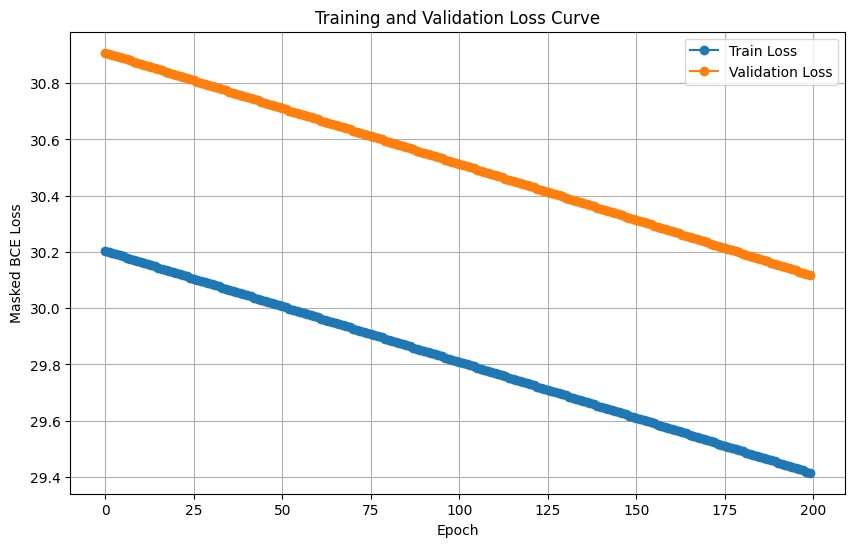

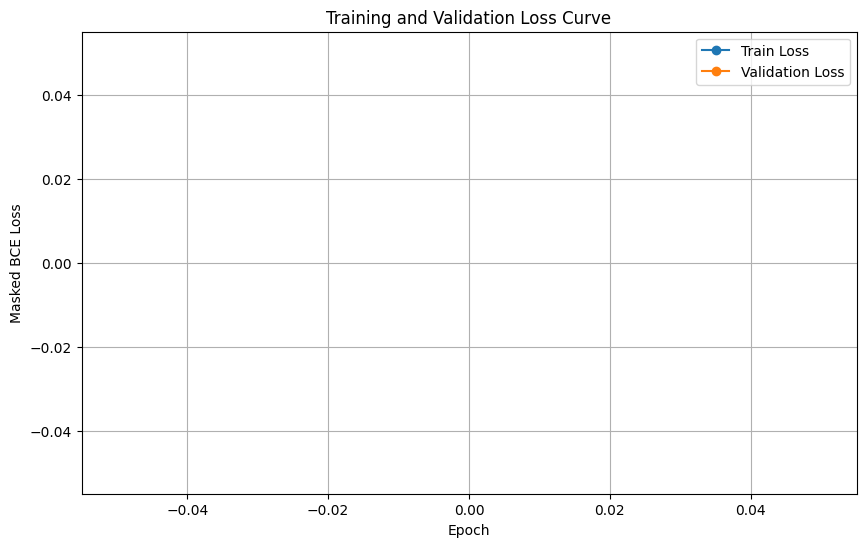

In [3]:
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_hyper = GAT_hyper(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

learning_rates = [1e-5, 1e-3, 1e-1]
best_loss = np.inf

for i in range(3):
    
    config = {
                'lr': learning_rates[i],
                'epochs': 200,
                'project_name': 'meetup-contagion-seeding',
                'run_name': 'GAT_hyper_run'
            }
    
    print("TESTING LEARNING RATE:", learning_rates[i])

    trainer_hyper = ImitationTrainer(
        model=model_hyper,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        static_graph=static_graph,
        config=config,
        use_wandb=False # Switch to False if wandb is not set up
    )

    print("\nStarting Training...")
    trainer_hyper.train()
    trainer_hyper.plot_losses()

    if model_hyper.losses[-1] < best_loss:
        best_loss = model_hyper.losses[-1]
        best_lr = learning_rates[i]

print("Best learning rate:", best_lr)

In [ ]:
print(static_graph)

In [ ]:
print(static_graph['edge_index_1'].shape)
print(static_graph['edge_attr_1'].shape)

In [ ]:
print(static_graph['edge_index_2'].shape)
print(static_graph['edge_attr_2'].shape)


#### Input: Simple and Hyper Graphs

In [ ]:
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_hybrid = GAT_simple_hyper(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)

config = {
    'lr': 1e-3,
    'epochs': 200,
    'project_name': 'meetup-contagion-seeding',
    'run_name': 'GAT_hyper_run'
}



trainer_hybrid = ImitationTrainer(
    model=model_hybrid,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if wandb is not set up
)
print("\nStarting Training...")
trainer_hybrid.train()
trainer_hybrid.plot_losses()